<a href="https://colab.research.google.com/github/MinjanaAP/Long-Jump-Performance-Analysis/blob/main/Module2_InjuryRisk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.2 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np
import random
from faker import Faker

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
OPTIMAL_RANGES = {
    "projection_angle": (18, 24),
    "lead_leg_thigh_angle": (65, 85),
    "minimum_knee_angle": (145, 165),
    "landing_knee_flexion": (90, 120),
    "trunk_angle": (10, 25)
}

In [4]:
fake = Faker()

data = []

for i in range(500):

    athlete_id = f"A{i+1:03}"

    age = random.randint(18, 30)

    projection_angle = round(random.uniform(10, 30), 2)
    lead_leg_thigh_angle = round(random.uniform(40, 100), 2)
    minimum_knee_angle = round(random.uniform(120, 175), 2)
    landing_knee_flexion = round(random.uniform(60, 140), 2)
    trunk_angle = round(random.uniform(0, 40), 2)

    previous_injury = random.choice([0, 1])

    # Technique Error Calculation
    error_score = (
        abs(projection_angle - 21) +
        abs(lead_leg_thigh_angle - 75) +
        abs(minimum_knee_angle - 155) +
        abs(landing_knee_flexion - 105) +
        abs(trunk_angle - 18)
    )

    # Injury Risk Logic
    if error_score < 40 and previous_injury == 0:
        injury_risk = "Low"
        injury_type = "None"

    elif error_score < 70:
        injury_risk = "Medium"
        injury_type = random.choice([
            "Ankle Sprain",
            "Hamstring Strain"
        ])

    else:
        injury_risk = "High"
        injury_type = random.choice([
            "Ankle Sprain",
            "Hamstring Strain",
            "Knee Injury"
        ])

    data.append([
        athlete_id,
        age,
        projection_angle,
        lead_leg_thigh_angle,
        minimum_knee_angle,
        landing_knee_flexion,
        trunk_angle,
        previous_injury,
        injury_type,
        injury_risk
    ])

In [13]:
columns = [
    "athlete_id",
    "age",
    "projection_angle",
    "lead_leg_thigh_angle",
    "minimum_knee_angle",
    "landing_knee_flexion",
    "trunk_angle",
    "previous_injury",
    "injury_type",
    "injury_risk"
]

df = pd.DataFrame(data, columns=columns)

df.head()

,athlete_id,age,projection_angle,lead_leg_thigh_angle,minimum_knee_angle,landing_knee_flexion,trunk_angle,previous_injury,injury_type,injury_risk
0,A001,22,26.34,92.32,135.83,137.27,20.95,0,Hamstring Strain,High
1,A002,26,17.17,72.96,145.20,65.70,25.82,0,Ankle Sprain,Medium
2,A003,26,17.67,68.13,168.25,110.69,6.48,1,Hamstring Strain,Medium
3,A004,27,21.95,76.49,157.03,73.41,38.12,0,Ankle Sprain,Medium
4,A005,21,26.22,49.71,167.90,70.30,1.93,0,Knee Injury,High


In [6]:
df.to_csv("synthetic_longjump_dataset.csv", index=False)

**Data Preprocessing**
1. Check Missing Values

In [7]:
df.isnull().sum()

,0
athlete_id,0
age,0
projection_angle,0
lead_leg_thigh_angle,0
minimum_knee_angle,0
landing_knee_flexion,0
trunk_angle,0
previous_injury,0
injury_type,0
injury_risk,0


2. Encode Categorical Data
| Original | Encoded |
| -------- | ------- |
| Low      | 0       |
| Medium   | 1       |
| High     | 2       |


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["injury_risk"] = le.fit_transform(df["injury_risk"])
df["injury_type"] = le.fit_transform(df["injury_type"])

3. Define Features and Labels

In [9]:
X = df.drop(["athlete_id", "injury_risk"], axis=1)

y = df["injury_risk"]

4. Train-Test Split

| Dataset       | Purpose              |
| ------------- | -------------------- |
| Training Data | Learn patterns       |
| Testing Data  | Evaluate performance |


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

5. Feature Scaling


> (value - mean) / standard deviation



In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train Machine Learning Models**

1. Logistic Regression

1.1. Visualize Injury Risk Distribution

---




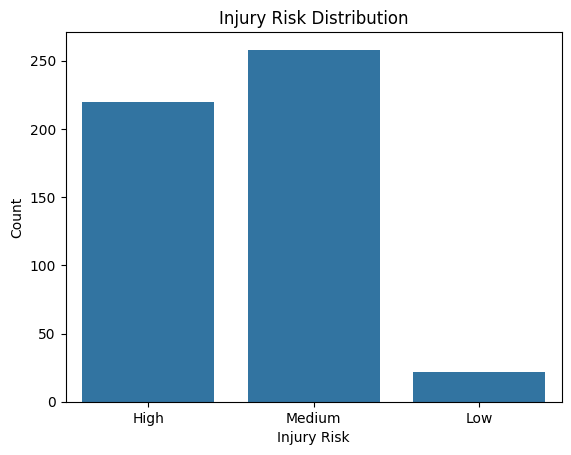

In [17]:
sns.countplot(x='injury_risk', data=df)

plt.title("Injury Risk Distribution")
plt.xlabel("Injury Risk")
plt.ylabel("Count")

plt.show()

1.2. Visualize Angle Distributions

---



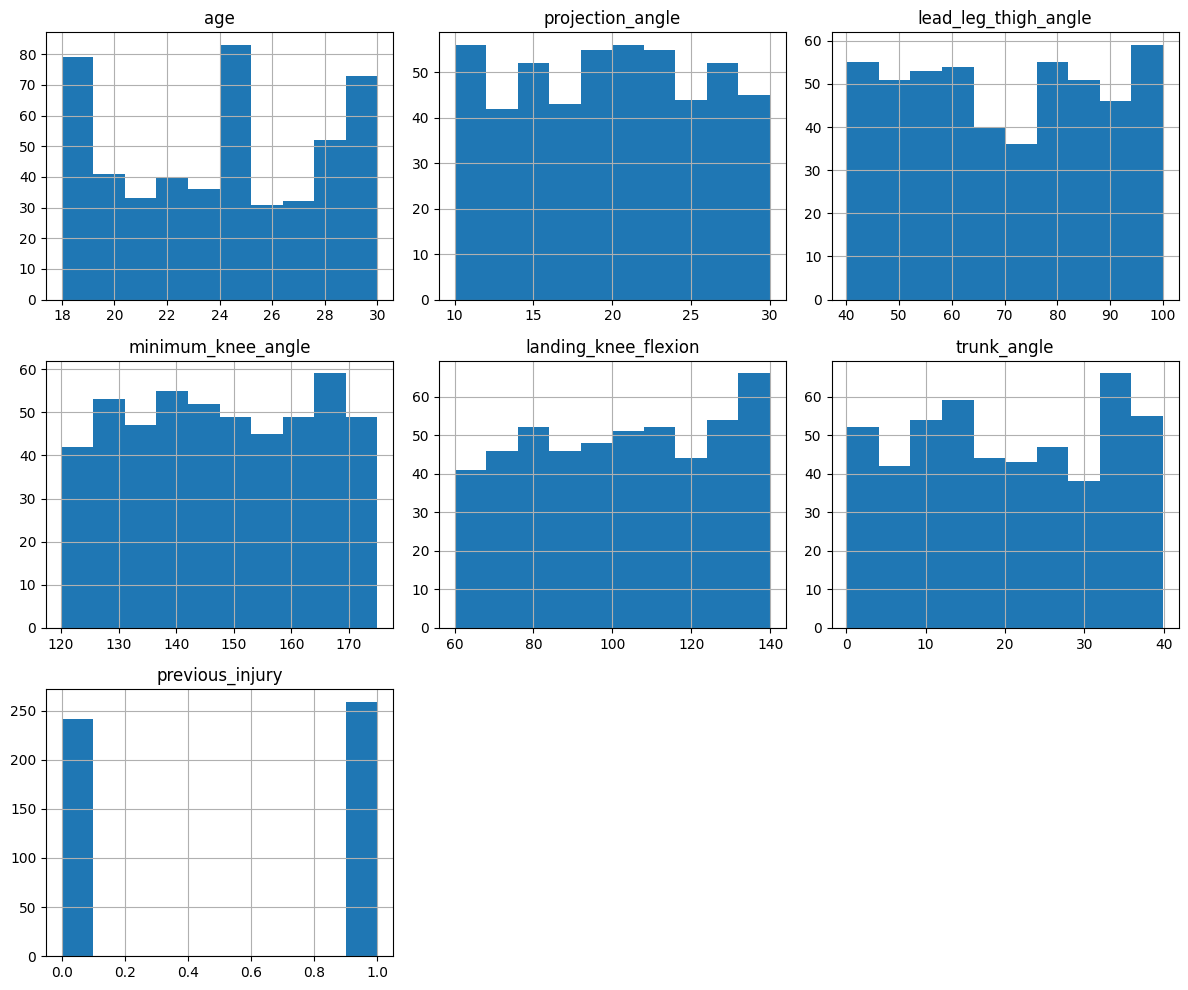

In [18]:
df.hist(figsize=(12,10))

plt.tight_layout()
plt.show()

1.3. Correlation Heatmap

---



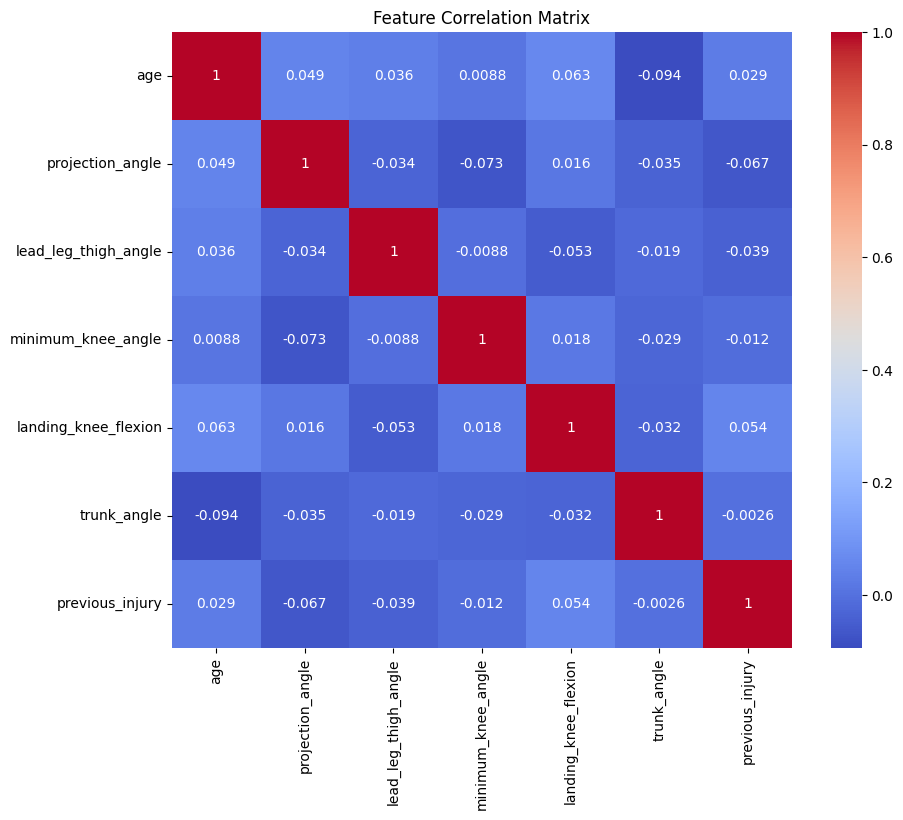

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()